# 6_CLUSTERING — QRF Mixture-of-Experts + Uncertainty Quantification

Implements the clustering-based Quantile Regression Forest (QRF) Mixture-of-Experts
framework from **Al-Aghbary et al. (2026, GJI)** applied to Antarctic and Greenland
subglacial heat-flow prediction.

| Section | Description |
|---------|-------------|
| 0 | Toggles & config |
| 1 | Load & clean reference data |
| 2 | K-Means cluster selection (N_CLUSTERS = 2–5) |
| 3 | Cluster diagnostics (PCA, violins, centroids) |
| 4 | Apply clusters to Antarctic & Greenland grids |
| 5 | QRF implementation (Meinshausen-style wrapper) |
| 6 | Per-cluster Expert + Baseline QRF training |
| 7 | 5-fold cross-validation & CV threshold derivation |
| 8 | Diagnostic field computation (reference points) |
| 9 | Apply MoE to target grids & write NetCDF |
| 10 | Diagnostic maps — Antarctica & Greenland |
| 11 | Supplementary figures |
| 12 | Save artefacts & summary |

**Prerequisites:** `1_Import.ipynb` and `4x_QRF.ipynb` have been run.
Required files: `data/IHFC_obs.parquet`, `data/antarctica.parquet`,
`data/greenland.parquet`, `output/models/qrf_artefacts.pkl`.


## Section 0 — Toggles & Config

In [1]:
# ── Execution toggles ────────────────────────────────────────────────────────
RUN_CLUSTERING   = True   # False → load saved kmeans from output/clustering/
RUN_QRF_TRAINING = True   # False → load saved expert artefacts
RUN_CV           = True   # False → load saved CV thresholds
RUN_GRID_APPLY   = True   # False → load saved target-grid NetCDFs

# ── Cluster sweep range (NOT the K used elsewhere in this project) ───────────
N_CLUSTERS_RANGE = range(2, 6)   # test N_CLUSTERS = 2, 3, 4, 5
N_CLUSTERS_BEST  = None          # set to int to override auto-selection

# ── Imports ───────────────────────────────────────────────────────────────────
import sys, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
from copy import deepcopy

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
import netCDF4 as nc

sys.path.insert(0, ".")
from config import (
    obs_model, parquet_ref, parquet_ant, parquet_grl,
    ant_Aq2_qrf_nc, grl_Kq2_qrf_nc,
    model_paths, sweep_dir,
    q_clip_min, q_clip_max,
    random_state, N_CV_FOLDS,
    QRF_N_ESTIMATORS, QRF_MAX_FEATURES, QRF_MIN_SAMPLES_LEAF, QRF_MAX_DEPTH, QRF_N_JOBS,
    ENTROPY_BINS, FIG_DPI, FIG_EXT,
    hf_cmap, unc_cmap,
    output_root, model_dir, sweep_dir,
    milli,  # 1/1000 — multiply W/m² → mW/m² display
)
warnings.filterwarnings('ignore')

# ── Output directories ────────────────────────────────────────────────────────
CLUSTER_DIR = Path('output/clustering')
FIG_DIR     = Path('fig/6_CLUSTERING')
for _d in [CLUSTER_DIR, FIG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def to_mW(x):  # convert W/m² array to mW/m² for display
    return np.asarray(x) / milli

print(f'obs_model features : {len(obs_model)}')
print(f'N_CLUSTERS sweep   : {list(N_CLUSTERS_RANGE)}')


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
obs_model features : 21
N_CLUSTERS sweep   : [2, 3, 4, 5]


## Section 1 — Load & Clean Reference Data

In [2]:
df_ref_raw = pd.read_parquet(parquet_ref)
print(f'Raw reference rows : {len(df_ref_raw):,}')

# Load QRF artefacts to get obs_sel (sweep-derived feature subset)
_qrf_bundle = pickle.load(open(model_paths['qrf'], 'rb'))
obs_sel = _qrf_bundle['obs_sel']   # feature-selected subset used in trained QRF
ref_scaler_orig = _qrf_bundle.get('scaler', None)  # may reuse if compatible
print(f'obs_sel ({len(obs_sel)} features): {obs_sel}')

# ── Filter: valid heat-flow range and complete obs_sel features ───────────────
cols_needed = obs_sel + ['q']
df_ref = df_ref_raw.dropna(subset=cols_needed).copy()
df_ref = df_ref[(df_ref['q'] >= q_clip_min) & (df_ref['q'] <= q_clip_max)].reset_index(drop=True)
print(f'After NaN/clip filter : {len(df_ref):,} rows')

# ── Feature matrix for QRF training (obs_sel, complete rows only) ─────────────
X_train = df_ref[obs_sel].values.astype(np.float64)
y_train = df_ref['q'].values.astype(np.float64)    # W/m²
print(f'Training matrix shape : {X_train.shape}')

# ── Feature matrix for clustering (obs_model, with median imputation) ─────────
# For clustering we use obs_model so spatial grids can be clustered via imputation.
# Compute training medians BEFORE any imputation for use on target grids.
cluster_cols = obs_model   # full 22-feature set for clustering
df_cluster_ref = df_ref_raw.dropna(subset=['q']).copy()
df_cluster_ref = df_cluster_ref[(df_cluster_ref['q'] >= q_clip_min) &
                                 (df_cluster_ref['q'] <= q_clip_max)].reset_index(drop=True)

# Compute column medians from reference (for imputation of target grids later)
cluster_medians = df_cluster_ref[cluster_cols].median()
X_clust_ref = df_cluster_ref[cluster_cols].fillna(cluster_medians).values.astype(np.float64)

# Standardise for clustering
clust_scaler = StandardScaler().fit(X_clust_ref)
X_clust_ref_sc = clust_scaler.transform(X_clust_ref)
print(f'Clustering matrix shape : {X_clust_ref_sc.shape}')
print(f'NaN after imputation    : {np.isnan(X_clust_ref_sc).sum()}')


Raw reference rows : 30,848
obs_sel (21 features): ['MOHO', 'MOHO_GRAV', 'DEM', 'LAB', 'FREE_AIR', 'BOUGUER', 'SI', 'GEOID', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_S70', 'REVEAL_S100', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'REVEAL_VP50VS80', 'LITH_RHO', 'CRUST_RHO', 'MAG_SEIS_MOHO', 'SEDIMENT', 'CTD', 'EMAG2_LOG']
After NaN/clip filter : 30,847 rows
Training matrix shape : (30847, 21)
Clustering matrix shape : (30848, 21)
NaN after imputation    : 0


## Section 2 — K-Means Cluster Selection

Sweep `N_CLUSTERS` = 2–5 using Elbow (WCSS) + Davies-Bouldin score.
Auto-selects best N by minimum Davies-Bouldin (ties broken by elbow inflection).


In [3]:
kmeans_models = {}   # N_CLUSTERS -> fitted KMeans
ref_labels    = {}   # N_CLUSTERS -> label array (len = len(df_cluster_ref))
diag_rows     = []

if RUN_CLUSTERING:
    for nc_val in N_CLUSTERS_RANGE:
        print(f'Fitting KMeans N={nc_val} ...', end=' ', flush=True)
        km = KMeans(n_clusters=nc_val, random_state=random_state, n_init=20, max_iter=500)
        km.fit(X_clust_ref_sc)
        kmeans_models[nc_val] = km
        ref_labels[nc_val]    = km.labels_

        sil = silhouette_score(X_clust_ref_sc, km.labels_,
                               sample_size=min(10_000, len(X_clust_ref_sc)),
                               random_state=random_state)
        db  = davies_bouldin_score(X_clust_ref_sc, km.labels_)
        sizes = pd.Series(km.labels_).value_counts().sort_index().tolist()
        diag_rows.append({'N_CLUSTERS': nc_val, 'Inertia': round(km.inertia_, 1),
                          'Silhouette': round(sil, 4), 'Davies-Bouldin': round(db, 4),
                          'Cluster_sizes': sizes})

        pkl_path = CLUSTER_DIR / f'kmeans_nc{nc_val}.pkl'
        pickle.dump(km, open(pkl_path, 'wb'))
        print(f'done. Inertia={km.inertia_:.1f}  DB={db:.4f}  Sil={sil:.4f}')
else:
    for nc_val in N_CLUSTERS_RANGE:
        pkl_path = CLUSTER_DIR / f'kmeans_nc{nc_val}.pkl'
        km = pickle.load(open(pkl_path, 'rb'))
        kmeans_models[nc_val] = km
        ref_labels[nc_val]    = km.predict(X_clust_ref_sc)
        sil = silhouette_score(X_clust_ref_sc, ref_labels[nc_val],
                               sample_size=min(10_000, len(X_clust_ref_sc)),
                               random_state=random_state)
        db  = davies_bouldin_score(X_clust_ref_sc, ref_labels[nc_val])
        sizes = pd.Series(ref_labels[nc_val]).value_counts().sort_index().tolist()
        diag_rows.append({'N_CLUSTERS': nc_val, 'Inertia': round(km.inertia_, 1),
                          'Silhouette': round(sil, 4), 'Davies-Bouldin': round(db, 4),
                          'Cluster_sizes': sizes})
        print(f'Loaded KMeans N={nc_val} from {pkl_path}')

diag_df = pd.DataFrame(diag_rows)

# ── Auto-select best N_CLUSTERS ───────────────────────────────────────────────
if N_CLUSTERS_BEST is None:
    best_idx = diag_df['Davies-Bouldin'].idxmin()
    N_CLUSTERS_BEST = int(diag_df.loc[best_idx, 'N_CLUSTERS'])
print(f'\nAuto-selected N_CLUSTERS_BEST = {N_CLUSTERS_BEST} (minimum Davies-Bouldin)')
print(diag_df.to_string(index=False))


Fitting KMeans N=2 ... done. Inertia=461445.6  DB=1.4867  Sil=0.2704
Fitting KMeans N=3 ... done. Inertia=399859.3  DB=1.4705  Sil=0.2505
Fitting KMeans N=4 ... done. Inertia=346985.3  DB=1.6106  Sil=0.2214
Fitting KMeans N=5 ... done. Inertia=320789.2  DB=1.6021  Sil=0.2147

Auto-selected N_CLUSTERS_BEST = 3 (minimum Davies-Bouldin)
 N_CLUSTERS  Inertia  Silhouette  Davies-Bouldin                   Cluster_sizes
          2 461445.6      0.2704          1.4867                  [12088, 18760]
          3 399859.3      0.2505          1.4705             [17090, 7816, 5942]
          4 346985.3      0.2214          1.6106       [7641, 5676, 10415, 7116]
          5 320789.2      0.2147          1.6021 [2776, 10390, 4046, 6470, 7166]


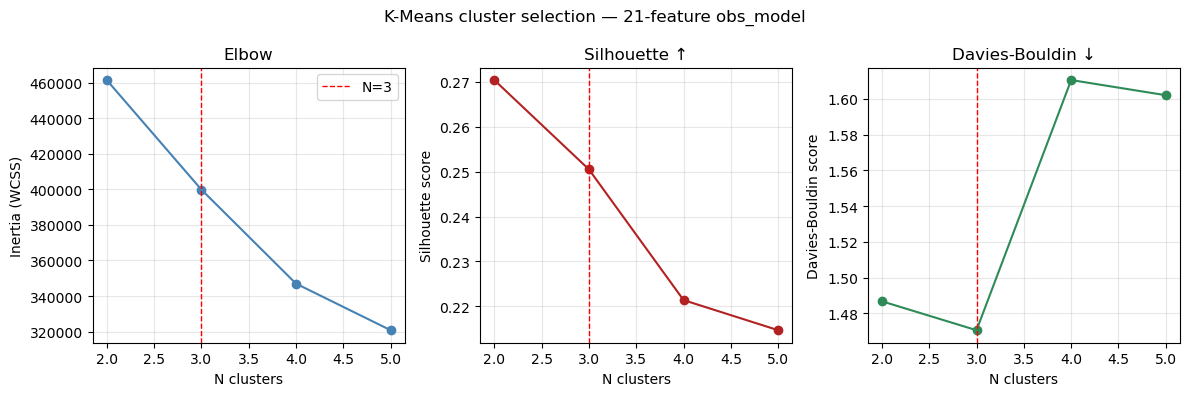

Saved → fig/6_CLUSTERING/S_cluster_selection.png


In [4]:
# ── Elbow / Silhouette / Davies-Bouldin 3-panel figure ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(diag_df['N_CLUSTERS'], diag_df['Inertia'], 'o-', color='steelblue', lw=1.5)
axes[0].axvline(N_CLUSTERS_BEST, color='red', lw=1, ls='--', label=f'N={N_CLUSTERS_BEST}')
axes[0].set_xlabel('N clusters'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(diag_df['N_CLUSTERS'], diag_df['Silhouette'], 'o-', color='firebrick', lw=1.5)
axes[1].axvline(N_CLUSTERS_BEST, color='red', lw=1, ls='--')
axes[1].set_xlabel('N clusters'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette ↑'); axes[1].grid(True, alpha=0.3)

axes[2].plot(diag_df['N_CLUSTERS'], diag_df['Davies-Bouldin'], 'o-', color='seagreen', lw=1.5)
axes[2].axvline(N_CLUSTERS_BEST, color='red', lw=1, ls='--')
axes[2].set_xlabel('N clusters'); axes[2].set_ylabel('Davies-Bouldin score')
axes[2].set_title('Davies-Bouldin ↓'); axes[2].grid(True, alpha=0.3)

fig.suptitle(f'K-Means cluster selection — {len(cluster_cols)}-feature obs_model', fontsize=12)
fig.tight_layout()
out = FIG_DIR / f'S_cluster_selection{FIG_EXT}'
fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved → {out}')


## Section 3 — Cluster Diagnostics

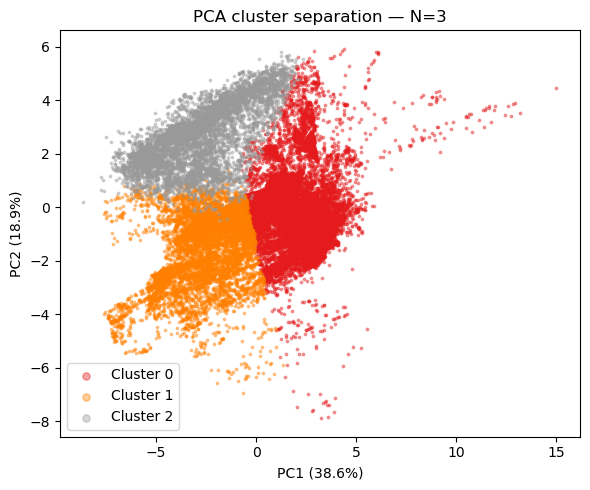

Saved → fig/6_CLUSTERING/S_cluster_pca.png


In [5]:
best_labels = ref_labels[N_CLUSTERS_BEST]
best_km     = kmeans_models[N_CLUSTERS_BEST]

# ── PCA 2-D scatter ───────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=random_state)
X_pca = pca.fit_transform(X_clust_ref_sc)
ev = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(6, 5))
cmap_disc = plt.get_cmap('Set1', N_CLUSTERS_BEST)
for ci in range(N_CLUSTERS_BEST):
    mask = best_labels == ci
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=3, alpha=0.4,
               color=cmap_disc(ci), label=f'Cluster {ci}')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)')
ax.set_title(f'PCA cluster separation — N={N_CLUSTERS_BEST}')
ax.legend(markerscale=3, loc='best')
fig.tight_layout()
out = FIG_DIR / f'S_cluster_pca{FIG_EXT}'
fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved → {out}')


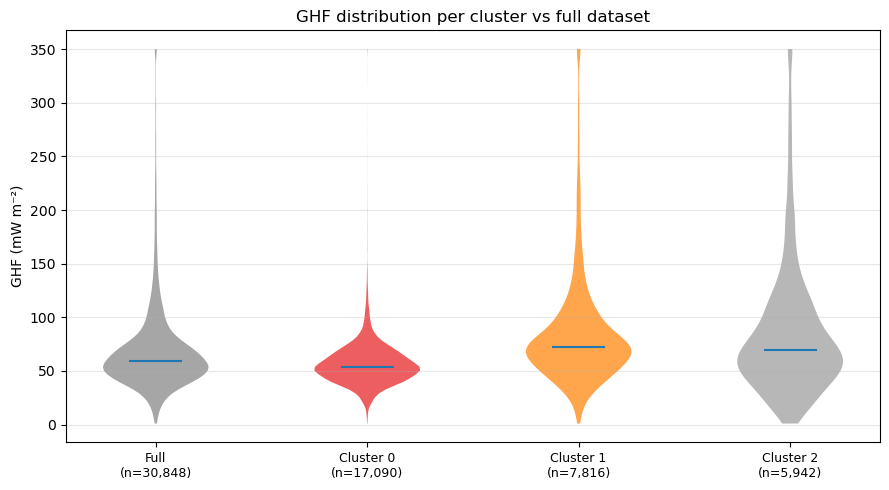

Saved → fig/6_CLUSTERING/S_cluster_violin.png


In [6]:
# ── GHF violin plots per cluster ─────────────────────────────────────────────
# Attach labels to cluster reference df (which has 'q')
df_cluster_ref['cluster'] = best_labels
q_mW = to_mW(df_cluster_ref['q'].values)

violin_data = [q_mW] + [to_mW(df_cluster_ref.loc[df_cluster_ref['cluster'] == ci, 'q'].values)
                         for ci in range(N_CLUSTERS_BEST)]
labels = [f'Full\n(n={len(q_mW):,})'] + \
         [f'Cluster {ci}\n(n={int((best_labels==ci).sum()):,})'
          for ci in range(N_CLUSTERS_BEST)]

fig, ax = plt.subplots(figsize=(3 + 2 * N_CLUSTERS_BEST, 5))
vp = ax.violinplot(violin_data, showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_alpha(0.7)
    body.set_facecolor(cmap_disc(i - 1) if i > 0 else 'grey')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('GHF (mW m⁻²)')
ax.set_title('GHF distribution per cluster vs full dataset')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
out = FIG_DIR / f'S_cluster_violin{FIG_EXT}'
fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved → {out}')


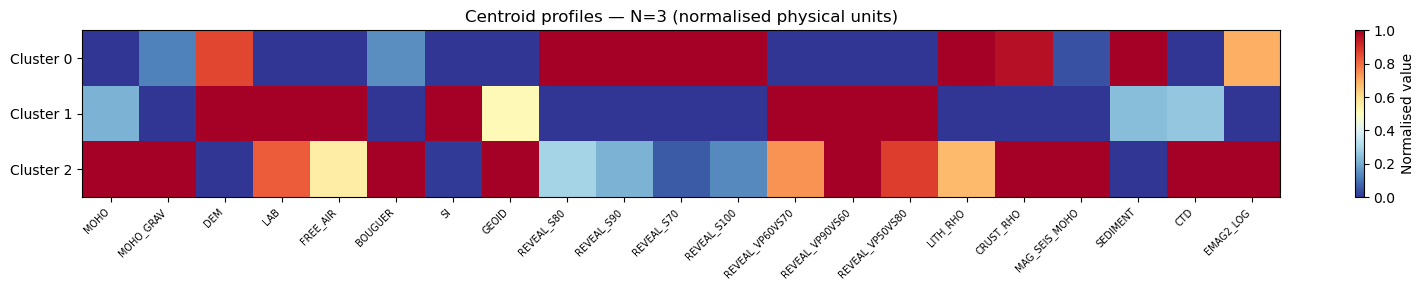

Saved → fig/6_CLUSTERING/S_cluster_centroids.png
Saved cluster_diagnostics.csv


In [7]:
# ── Centroid heatmap (normalised physical units) ──────────────────────────────
centres_phys = clust_scaler.inverse_transform(best_km.cluster_centers_)
df_centres   = pd.DataFrame(centres_phys, columns=cluster_cols)
df_norm      = (df_centres - df_centres.min()) / \
               (df_centres.max() - df_centres.min() + 1e-12)

fig, ax = plt.subplots(figsize=(16, 3))
im = ax.imshow(df_norm.values, aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(cluster_cols)))
ax.set_xticklabels(cluster_cols, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(N_CLUSTERS_BEST))
ax.set_yticklabels([f'Cluster {i}' for i in range(N_CLUSTERS_BEST)])
ax.set_title(f'Centroid profiles — N={N_CLUSTERS_BEST} (normalised physical units)')
plt.colorbar(im, ax=ax, label='Normalised value')
fig.tight_layout()
out = FIG_DIR / f'S_cluster_centroids{FIG_EXT}'
fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved → {out}')

diag_df.to_csv(CLUSTER_DIR / 'cluster_diagnostics.csv', index=False)
print('Saved cluster_diagnostics.csv')


## Section 4 — Apply Cluster Labels to Target Grids

NaN cells in target grids are filled with training-set column medians before
clustering (so every subglacial grid cell receives a valid cluster label).
The imputation fills only for clustering; QRF inference handles NaNs separately.


In [9]:
DOMAINS = {'ant': parquet_ant, 'grl': parquet_grl}
target_labels = {}   # domain -> label array (len = grid rows)

for domain, pq_path in DOMAINS.items():
    print(f'\n── {domain.upper()} ──')
    df_tgt = pd.read_parquet(pq_path)
    print(f'  Grid rows : {len(df_tgt):,}')

    # Report any missing cluster features
    missing = [f for f in cluster_cols if f not in df_tgt.columns]
    if missing:
        print(f'  Missing features (will impute): {missing}')
        for m in missing:
            df_tgt[m] = np.nan

    # Median imputation using training medians
    X_tgt = df_tgt[cluster_cols].replace([np.inf, -np.inf], np.nan) \
                             .fillna(cluster_medians) \
                             .values.astype(np.float64)

    # Standardise and predict
    X_tgt_sc = clust_scaler.transform(X_tgt)
    lbl = kmeans_models[N_CLUSTERS_BEST].predict(X_tgt_sc).astype(np.int16)
    target_labels[domain] = lbl

    counts = pd.Series(lbl).value_counts().sort_index().to_dict()
    print(f'  Cluster sizes (N={N_CLUSTERS_BEST}): {counts}')

    # Save with lat/lon (or x/y) coordinates
    coord_cols = [c for c in ['lon', 'lat', 'x', 'y'] if c in df_tgt.columns]
    out_df = df_tgt[coord_cols].copy()
    out_df[f'cluster_n{N_CLUSTERS_BEST}'] = lbl
    out_path = CLUSTER_DIR / f'{domain}_cluster_labels.parquet'
    out_df.to_parquet(out_path, index=False)
    print(f'  Saved → {out_path}')



── ANT ──
  Grid rows : 1,779,556
  Cluster sizes (N=3): {0: 932182, 1: 64121, 2: 783253}
  Saved → output/clustering/ant_cluster_labels.parquet

── GRL ──
  Grid rows : 172,360
  Cluster sizes (N=3): {0: 118502, 1: 16729, 2: 37129}
  Saved → output/clustering/grl_cluster_labels.parquet


## Section 5 — QRF Implementation (Meinshausen 2006 wrapper)

Extends `sklearn.RandomForestRegressor` to:
- Retain all training response values in each terminal node
- Estimate quantiles empirically from retained leaf values
- Decompose predictive variance into aleatoric (within-leaf) and epistemic (between-tree)

Reference: Meinshausen N. (2006). Quantile Regression Forests. JMLR 7:983–999.
Implementation follows Al-Aghbary et al. (2026, GJI) Appendix A4.


In [10]:
class QuantileRegressionForest(RandomForestRegressor):
    """
    Meinshausen (2006) Quantile Regression Forest.
    Wraps sklearn RandomForestRegressor; retains all leaf response values
    for empirical quantile estimation and aleatoric/epistemic decomposition.
    """

    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight=sample_weight)
        # For each tree, map leaf_node_id -> array of training y values
        leaf_ids = self.apply(X)           # shape (n_samples, n_estimators)
        self._leaf_y = []
        for ti, tree in enumerate(self.estimators_):
            leaf_map = {}
            for sample_i, node_id in enumerate(leaf_ids[:, ti]):
                leaf_map.setdefault(int(node_id), []).append(y[sample_i])
            # Convert lists to arrays
            self._leaf_y.append(
                {nid: np.array(vals) for nid, vals in leaf_map.items()}
            )
        return self

    def _get_leaf_values(self, X):
        """Return list of per-tree leaf-y arrays for rows in X."""
        leaf_ids = self.apply(X)   # (n_samples, n_estimators)
        n_samples = X.shape[0]
        # per_sample_trees[i] = list of y-arrays (one per tree) for sample i
        per_sample = []
        for i in range(n_samples):
            tree_vals = []
            for ti in range(self.n_estimators):
                nid = int(leaf_ids[i, ti])
                tree_vals.append(self._leaf_y[ti].get(nid, np.array([])))
            per_sample.append(tree_vals)
        return per_sample

    def predict_quantile(self, X, quantiles):
        """
        Predict one or more quantiles for each sample in X.
        Returns array shape (n_samples,) for scalar quantile,
        or (n_samples, len(quantiles)) for a list.
        """
        scalar = np.isscalar(quantiles)
        quantiles = np.atleast_1d(quantiles)
        leaf_ids  = self.apply(X)
        n_samples = X.shape[0]
        results   = np.empty((n_samples, len(quantiles)))
        for i in range(n_samples):
            # Pool all leaf values across trees
            pooled = np.concatenate(
                [self._leaf_y[ti].get(int(leaf_ids[i, ti]), np.array([]))
                 for ti in range(self.n_estimators)]
            )
            if len(pooled) == 0:
                results[i] = np.nan
            else:
                results[i] = np.quantile(pooled, quantiles)
        return results[:, 0] if scalar else results

    def predict_mean(self, X):
        """Ensemble mean prediction (same as RandomForest.predict)."""
        return super().predict(X)

    def variance_decomposition(self, X):
        """
        Returns (aleatoric, epistemic) variance arrays, shape (n_samples,).

        Aleatoric  σ²_a(x) = mean of within-leaf variances across trees    (eq. 2)
        Epistemic  σ²_e(x) = variance of per-tree mean predictions         (eq. 3)

        Reference: Al-Aghbary et al. (2026) eqs 2–4; Meinshausen (2006).
        """
        leaf_ids  = self.apply(X)   # (n_samples, n_estimators)
        n_samples = X.shape[0]
        aleatoric = np.zeros(n_samples)
        tree_means = np.zeros((n_samples, self.n_estimators))

        for ti in range(self.n_estimators):
            for i in range(n_samples):
                nid = int(leaf_ids[i, ti])
                vals = self._leaf_y[ti].get(nid, np.array([]))
                if len(vals) >= 2:
                    aleatoric[i]    += np.var(vals, ddof=1)
                    tree_means[i, ti] = np.mean(vals)
                else:
                    tree_means[i, ti] = vals[0] if len(vals) == 1 else np.nan

        aleatoric  /= self.n_estimators            # average across trees
        ens_mean    = np.nanmean(tree_means, axis=1)
        epistemic   = np.nanmean((tree_means - ens_mean[:, None])**2, axis=1)
        return aleatoric, epistemic

    def robustness(self, X, n_bins=50):
        """
        Robustness R(x) = 1 − H_n(x)  where H_n is normalised Shannon entropy
        of the pooled predictive distribution, discretised into n_bins equal-width bins.

        Reference: Al-Aghbary et al. (2026) Appendix A1.1, eqs A1–A2.
        """
        leaf_ids  = self.apply(X)
        n_samples = X.shape[0]
        R = np.zeros(n_samples)

        for i in range(n_samples):
            pooled = np.concatenate(
                [self._leaf_y[ti].get(int(leaf_ids[i, ti]), np.array([]))
                 for ti in range(self.n_estimators)]
            )
            if len(pooled) < 2:
                R[i] = 1.0
                continue
            counts, _ = np.histogram(pooled, bins=n_bins)
            pk = counts / counts.sum()
            pk = pk[pk > 0]
            Hn = -np.sum(pk * np.log(pk)) / np.log(n_bins)   # normalised entropy
            R[i] = 1.0 - Hn
        return R


print('QuantileRegressionForest class defined.')


QuantileRegressionForest class defined.


## Section 6 — Per-Cluster Expert Training (Mixture-of-Experts)

Trains one QRF Expert per cluster (using the rows from `df_ref` assigned to that cluster)
plus a single global Baseline QRF (no clustering) for comparison.

Tree depth is scaled to dataset size following the paper:
`max_depth = round(0.9 * log2(n_cluster))`


In [12]:
# Load hyperparameters from sweep JSON if available, else use config defaults
_qrf_param_path = sweep_dir / 'qrf_params.json'
if _qrf_param_path.exists():
    _qrf_params = json.loads(_qrf_param_path.read_text())
    N_TREES   = int(_qrf_params.get('n_estimators', QRF_N_ESTIMATORS))
    MAX_FEAT  = _qrf_params.get('max_features', QRF_MAX_FEATURES)
    MIN_LEAF  = int(_qrf_params.get('min_samples_leaf', max(QRF_MIN_SAMPLES_LEAF, 3)))
    print(f'Loaded QRF params from {_qrf_param_path}')
else:
    N_TREES  = QRF_N_ESTIMATORS
    MAX_FEAT = QRF_MAX_FEATURES
    MIN_LEAF = max(QRF_MIN_SAMPLES_LEAF, 3)  # min 3 for variance decomposition
    print('Using config defaults for QRF hyperparameters.')

print(f'N_TREES={N_TREES}  MAX_FEAT={MAX_FEAT}  MIN_LEAF={MIN_LEAF}')

# ── Map training rows to cluster labels ───────────────────────────────────────
# df_ref rows and df_cluster_ref rows are aligned on original index — re-sync.
# Both were filtered from df_ref_raw; df_ref uses obs_sel completeness.
# We predict cluster labels for df_ref rows using the fitted KMeans.
X_ref_for_clust = df_ref[cluster_cols].replace([np.inf, -np.inf], np.nan) \
                                       .fillna(cluster_medians) \
                                       .values.astype(np.float64)
X_ref_clust_sc  = clust_scaler.transform(X_ref_for_clust)
train_cluster_labels = kmeans_models[N_CLUSTERS_BEST].predict(X_ref_clust_sc).astype(int)
df_ref = df_ref.copy()
df_ref['cluster'] = train_cluster_labels
print(f'Training cluster sizes: {pd.Series(train_cluster_labels).value_counts().sort_index().to_dict()}')


Using config defaults for QRF hyperparameters.
N_TREES=2000  MAX_FEAT=0.3  MIN_LEAF=3
Training cluster sizes: {0: 17090, 1: 7816, 2: 5941}


In [13]:
expert_models  = {}   # cluster_id -> fitted QuantileRegressionForest
baseline_model = None

if RUN_QRF_TRAINING:
    # ── Baseline (global, no clustering) ─────────────────────────────────────
    n_base  = len(X_train)
    md_base = max(5, round(0.9 * np.log2(n_base)))
    print(f'\nFitting Baseline QRF  n={n_base:,}  max_depth={md_base}', end=' ... ', flush=True)
    baseline_model = QuantileRegressionForest(
        n_estimators=N_TREES, max_features=MAX_FEAT,
        min_samples_leaf=MIN_LEAF, max_depth=md_base,
        n_jobs=QRF_N_JOBS, random_state=random_state
    )
    baseline_model.fit(X_train, y_train)
    print('done.')

    # ── Per-cluster Experts ───────────────────────────────────────────────────
    for ci in range(N_CLUSTERS_BEST):
        mask = train_cluster_labels == ci
        Xc   = X_train[mask]
        yc   = y_train[mask]
        n_c  = len(yc)
        md_c = max(5, round(0.9 * np.log2(n_c)))
        print(f'Fitting Expert {ci}  n={n_c:,}  max_depth={md_c}', end=' ... ', flush=True)
        exp = QuantileRegressionForest(
            n_estimators=N_TREES, max_features=MAX_FEAT,
            min_samples_leaf=MIN_LEAF, max_depth=md_c,
            n_jobs=QRF_N_JOBS, random_state=random_state
        )
        exp.fit(Xc, yc)
        expert_models[ci] = exp
        print('done.')

    # Save artefacts
    expert_artefacts = dict(
        N_CLUSTERS_BEST=N_CLUSTERS_BEST,
        obs_sel=obs_sel,
        cluster_cols=cluster_cols,
        cluster_medians=cluster_medians,
        clust_scaler=clust_scaler,
        kmeans_model=kmeans_models[N_CLUSTERS_BEST],
        baseline_model=baseline_model,
        expert_models=expert_models,
    )
    pkl_path = CLUSTER_DIR / f'expert_qrf_n{N_CLUSTERS_BEST}.pkl'
    pickle.dump(expert_artefacts, open(pkl_path, 'wb'))
    print(f'\nSaved expert artefacts → {pkl_path}')
else:
    pkl_path = CLUSTER_DIR / f'expert_qrf_n{N_CLUSTERS_BEST}.pkl'
    ea = pickle.load(open(pkl_path, 'rb'))
    baseline_model = ea['baseline_model']
    expert_models  = ea['expert_models']
    print(f'Loaded expert artefacts from {pkl_path}')



Fitting Baseline QRF  n=30,847  max_depth=13 ... done.
Fitting Expert 0  n=17,090  max_depth=13 ... done.
Fitting Expert 1  n=7,816  max_depth=12 ... done.
Fitting Expert 2  n=5,941  max_depth=11 ... done.

Saved expert artefacts → output/clustering/expert_qrf_n3.pkl


## Section 7 — 5-Fold Cross-Validation & CV Threshold Derivation

Runs stratified 5-fold CV over the reference training set.
Computes out-of-fold (OOF) predictions for both Baseline and MoE,
then derives the bandwidth/robustness/variance thresholds needed for
the confidence and explainability maps (Sections 8–10).


In [15]:
from sklearn.metrics import r2_score, mean_squared_error

if RUN_CV:
    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=random_state)
    strat_labels = train_cluster_labels

    oof_base = dict(mean=[], q25=[], q75=[], aleat=[], epist=[], robust=[], y_true=[])
    oof_moe  = dict(mean=[], q25=[], q75=[], aleat=[], epist=[], robust=[], y_true=[])

    print(f'Running {N_CV_FOLDS}-fold CV ...')
    for fold_i, (train_idx, val_idx) in enumerate(skf.split(X_train, strat_labels)):
        print(f'  Fold {fold_i+1}/{N_CV_FOLDS}', end=' ', flush=True)
        Xtr, ytr   = X_train[train_idx], y_train[train_idx]
        Xval, yval = X_train[val_idx],   y_train[val_idx]
        cl_tr      = strat_labels[train_idx]
        cl_val     = strat_labels[val_idx]

        # ── Baseline fold ────────────────────────────────────────────────────
        n_b    = len(ytr)
        md_b   = max(5, round(0.9 * np.log2(n_b)))
        base_f = QuantileRegressionForest(
            n_estimators=N_TREES, max_features=MAX_FEAT,
            min_samples_leaf=MIN_LEAF, max_depth=md_b,
            n_jobs=QRF_N_JOBS, random_state=random_state
        ).fit(Xtr, ytr)
        oof_base['mean'].append(base_f.predict_mean(Xval))
        oof_base['q25'].append(base_f.predict_quantile(Xval, 0.25))
        oof_base['q75'].append(base_f.predict_quantile(Xval, 0.75))
        al_b, ep_b = base_f.variance_decomposition(Xval)
        oof_base['aleat'].append(al_b)
        oof_base['epist'].append(ep_b)
        oof_base['robust'].append(base_f.robustness(Xval, n_bins=ENTROPY_BINS))
        oof_base['y_true'].append(yval)

        # ── MoE fold ─────────────────────────────────────────────────────────
        experts_f = {}
        for ci in np.unique(cl_tr):
            mask_c = cl_tr == ci
            Xc, yc = Xtr[mask_c], ytr[mask_c]
            n_c    = len(yc)
            md_c   = max(5, round(0.9 * np.log2(n_c)))
            experts_f[ci] = QuantileRegressionForest(
                n_estimators=N_TREES, max_features=MAX_FEAT,
                min_samples_leaf=MIN_LEAF, max_depth=md_c,
                n_jobs=QRF_N_JOBS, random_state=random_state
            ).fit(Xc, yc)

        moe_mean   = np.full(len(yval), np.nan)
        moe_q25    = np.full(len(yval), np.nan)
        moe_q75    = np.full(len(yval), np.nan)
        moe_aleat  = np.full(len(yval), np.nan)
        moe_epist  = np.full(len(yval), np.nan)
        moe_robust = np.full(len(yval), np.nan)
        for ci, exp_f in experts_f.items():
            m = cl_val == ci
            if m.sum() == 0:
                continue
            moe_mean[m]   = exp_f.predict_mean(Xval[m])
            moe_q25[m]    = exp_f.predict_quantile(Xval[m], 0.25)
            moe_q75[m]    = exp_f.predict_quantile(Xval[m], 0.75)
            al_m, ep_m    = exp_f.variance_decomposition(Xval[m])
            moe_aleat[m]  = al_m
            moe_epist[m]  = ep_m
            moe_robust[m] = exp_f.robustness(Xval[m], n_bins=ENTROPY_BINS)

        oof_moe['mean'].append(moe_mean)
        oof_moe['q25'].append(moe_q25)
        oof_moe['q75'].append(moe_q75)
        oof_moe['aleat'].append(moe_aleat)
        oof_moe['epist'].append(moe_epist)
        oof_moe['robust'].append(moe_robust)   # fixed: was 'robustness'
        oof_moe['y_true'].append(yval)
        print('done.', flush=True)

    # Concatenate all folds
    for d in [oof_base, oof_moe]:
        for key in list(d.keys()):
            d[key] = np.concatenate(d[key])

    print('CV complete.')

Running 5-fold CV ...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.
CV complete.


In [16]:
if RUN_CV:
    # ── CV performance metrics ────────────────────────────────────────────────
    for name, oof in [('Baseline', oof_base), ('MoE', oof_moe)]:
        rmse = np.sqrt(mean_squared_error(oof['y_true'], oof['mean']))
        r2   = r2_score(oof['y_true'], oof['mean'])
        picp = np.mean((oof['y_true'] >= oof['q25']) & (oof['y_true'] <= oof['q75']))
        bw   = np.mean(0.5 * (oof['q75'] - oof['q25']))
        print(f'{name:10s}  RMSE={to_mW(rmse):.2f} mW/m²  R²={r2:.4f}  '
              f'PICP={picp:.3f}  BW={to_mW(bw):.2f} mW/m²')

    # ── Derive CV thresholds ──────────────────────────────────────────────────
    bw_cv        = 0.5 * (oof_moe['q75'] - oof_moe['q25'])
    b_mean_cv    = float(np.nanmean(bw_cv))
    b_excess_cv  = float(np.nanmean(bw_cv[bw_cv > b_mean_cv]))
    b_deficit_cv = float(np.nanmean(bw_cv[bw_cv < b_mean_cv]))
    R_cv25       = float(np.nanquantile(oof_moe['robust'], 0.25))
    R_cv75       = float(np.nanquantile(oof_moe['robust'], 0.75))
    A50_cv       = float(np.nanmedian(oof_moe['aleat']))
    E50_cv       = float(np.nanmedian(oof_moe['epist']))

    thresholds = dict(
        b_mean_cv=b_mean_cv, b_excess_cv=b_excess_cv, b_deficit_cv=b_deficit_cv,
        R_cv25=R_cv25, R_cv75=R_cv75, A50_cv=A50_cv, E50_cv=E50_cv,
    )
    thresh_path = CLUSTER_DIR / 'cv_thresholds.json'
    with open(thresh_path, 'w') as fp:
        json.dump({k: float(v) for k, v in thresholds.items()}, fp, indent=2)
    print(f'\nCV thresholds saved → {thresh_path}')
    for k, v in thresholds.items():
        print(f'  {k:20s} = {to_mW(v):.5f} mW/m²' if 'b_' in k
              else f'  {k:20s} = {v:.5f}')

else:
    thresholds   = json.loads((CLUSTER_DIR / 'cv_thresholds.json').read_text())
    b_mean_cv    = thresholds['b_mean_cv']
    b_excess_cv  = thresholds['b_excess_cv']
    b_deficit_cv = thresholds['b_deficit_cv']
    R_cv25       = thresholds['R_cv25']
    R_cv75       = thresholds['R_cv75']
    A50_cv       = thresholds['A50_cv']
    E50_cv       = thresholds['E50_cv']
    print('Loaded CV thresholds from file.')

Baseline    RMSE=33.68 mW/m²  R²=0.4214  PICP=0.531  BW=13.86 mW/m²
MoE         RMSE=33.61 mW/m²  R²=0.4237  PICP=0.526  BW=13.69 mW/m²

CV thresholds saved → output/clustering/cv_thresholds.json
  b_mean_cv            = 13.69270 mW/m²
  b_excess_cv          = 24.26978 mW/m²
  b_deficit_cv         = 8.38589 mW/m²
  R_cv25               = 0.27348
  R_cv75               = 0.48815
  A50_cv               = 0.00044
  E50_cv               = 0.00009


## Section 8 — Diagnostic Field Computation (Helper Functions)

Implements the five diagnostic fields for any set of QRF predictions:
1. **Bandwidth** b = ½(Q0.75 − Q0.25)  (eq. 5)
2. **Variance** σ²_t = σ²_a + σ²_e  (eq. 1)
3. **Robustness** R = 1 − H_n  (eqs A1–A2)
4. **Confidence** — 5-category map (eqs 6–10)
5. **Explainability** — 4-category map (eqs 11–14)


In [17]:
# Confidence category codes (eqs 6–10)
CONF_HIGH        = 0   # b ≤ b_mean_cv  AND  R ≥ R_cv75
CONF_MODERATE    = 1   # b ≤ b_mean_cv  AND  R_cv25 ≤ R < R_cv75
CONF_LOW         = 2   # b > b_mean_cv  AND  R < R_cv25
CONF_OVER        = 3   # b ≤ b_deficit_cv  AND  R < R_cv25   (overconfident)
CONF_UNDER       = 4   # b ≥ b_excess_cv   AND  R ≥ R_cv75  (underconfident)

CONF_LABELS  = ['High', 'Moderate', 'Low', 'Overconfident', 'Underconfident']
CONF_COLORS  = ['#2ca25f', '#99d8c9', '#fc8d59', '#d7191c', '#ffd700']

# Explainability category codes (eqs 11–14 )
EXPL_LOW     = 0   # σ²_a < A50  AND  σ²_e < E50  → low uncertainty
EXPL_EPIST   = 1   # σ²_a < A50  AND  σ²_e ≥ E50  → epistemic-dominated
EXPL_ALEAT   = 2   # σ²_a ≥ A50  AND  σ²_e < E50  → aleatoric-dominated
EXPL_HIGH    = 3   # σ²_a ≥ A50  AND  σ²_e ≥ E50  → high uncertainty

EXPL_LABELS  = ['Low uncertainty', 'Epistemic-dominated',
                'Aleatoric-dominated', 'High uncertainty']
EXPL_COLORS  = ['#2166ac', '#abd9e9', '#fdae61', '#d73027']


def compute_diagnostics(model_or_dict, X, cluster_labels, thresholds, n_bins=ENTROPY_BINS):
    """
    Compute all five diagnostic fields for an array of prediction inputs X.

    Parameters
    ----------
    model_or_dict : QuantileRegressionForest (Baseline)
                    OR dict {cluster_id: QuantileRegressionForest} (MoE)
    X             : np.ndarray (n_samples, n_features)
    cluster_labels: np.ndarray (n_samples,) int — cluster assignment for each row
    thresholds    : dict — from CV (b_mean_cv, R_cv25, R_cv75, A50_cv, E50_cv, ...)
    n_bins        : int — entropy bins for robustness

    Returns
    -------
    dict with keys: mean, q25, q75, bandwidth, variance_total,
                    variance_aleatoric, variance_epistemic,
                    robustness, confidence (int), explainability (int)
    """
    n = X.shape[0]
    out = {k: np.full(n, np.nan) for k in
           ['mean','q25','q75','bandwidth','variance_total',
            'variance_aleatoric','variance_epistemic','robustness']}
    out['confidence']    = np.full(n, -1, dtype=np.int8)
    out['explainability'] = np.full(n, -1, dtype=np.int8)

    if isinstance(model_or_dict, dict):
        models_by_cluster = model_or_dict
    else:
        # Baseline: use same model for all clusters
        models_by_cluster = {ci: model_or_dict for ci in np.unique(cluster_labels)}

    for ci, model in models_by_cluster.items():
        mask = cluster_labels == ci
        if mask.sum() == 0:
            continue
        Xc = X[mask]

        out['mean'][mask]  = model.predict_mean(Xc)
        out['q25'][mask]   = model.predict_quantile(Xc, 0.25)
        out['q75'][mask]   = model.predict_quantile(Xc, 0.75)
        al, ep             = model.variance_decomposition(Xc)
        out['variance_aleatoric'][mask] = al
        out['variance_epistemic'][mask] = ep
        out['robustness'][mask] = model.robustness(Xc, n_bins=n_bins)

    out['bandwidth']       = 0.5 * (out['q75'] - out['q25'])
    out['variance_total']  = out['variance_aleatoric'] + out['variance_epistemic']

    # ── Confidence map (eqs 6–10) ─────────────────────────────────────────────
    b   = out['bandwidth']
    R   = out['robustness']
    bm  = thresholds['b_mean_cv']
    bex = thresholds['b_excess_cv']
    bdf = thresholds['b_deficit_cv']
    r25 = thresholds['R_cv25']
    r75 = thresholds['R_cv75']

    conf = out['confidence']
    conf[( b <= bm  ) & (R >= r75)]  = CONF_HIGH
    conf[( b <= bm  ) & (R >= r25) & (R < r75)] = CONF_MODERATE
    conf[( b > bm   ) & (R < r25)]  = CONF_LOW
    conf[( b <= bdf ) & (R < r25)]  = CONF_OVER
    conf[( b >= bex ) & (R >= r75)] = CONF_UNDER
    # Remaining unclassified → moderate (catch-all)
    conf[conf == -1] = CONF_MODERATE

    # ── Explainability map (eqs 11–14) ────────────────────────────────────────
    sa  = out['variance_aleatoric']
    se  = out['variance_epistemic']
    A50 = thresholds['A50_cv']
    E50 = thresholds['E50_cv']

    expl = out['explainability']
    expl[(sa < A50) & (se < E50)] = EXPL_LOW
    expl[(sa < A50) & (se >= E50)] = EXPL_EPIST
    expl[(sa >= A50) & (se < E50)] = EXPL_ALEAT
    expl[(sa >= A50) & (se >= E50)] = EXPL_HIGH

    return out


print('compute_diagnostics() helper defined.')


compute_diagnostics() helper defined.


## Section 9 — Apply MoE to Target Grids & Write NetCDF

For each domain (Antarctica, Greenland):
1. Load cluster labels from Section 4
2. Load obs_sel features from the parquet grid
3. Route each grid cell to its cluster Expert
4. Compute all 5 diagnostic fields
5. Append new variables to the existing QRF NetCDF (creates if absent)


In [ ]:
DOMAIN_CONFIG = {
    'ant': dict(parquet=parquet_ant, nc_path=ant_Aq2_qrf_nc,
                x_col='x', y_col='y', epsg=3031),
    'grl': dict(parquet=parquet_grl, nc_path=grl_Kq2_qrf_nc,
                x_col='x', y_col='y', epsg=3413),
}

grid_diag = {}  # domain -> diagnostics dict

if RUN_GRID_APPLY:
    for domain, cfg in DOMAIN_CONFIG.items():
        print(f'\n── {domain.upper()} ──')
        df_tgt   = pd.read_parquet(cfg['parquet'])
        lbl_path = CLUSTER_DIR / f'{domain}_cluster_labels.parquet'
        df_lbl   = pd.read_parquet(lbl_path)
        cl_col   = f'cluster_n{N_CLUSTERS_BEST}'
        cluster_lbl = df_lbl[cl_col].values.astype(int)

        # Build feature matrix for QRF inference (obs_sel, fill NaN with training medians)
        # Note: use obs_sel medians from training set for obs_sel NaN imputation
        obs_sel_medians = pd.Series(
            np.nanmedian(X_train, axis=0), index=obs_sel
        )
        missing_sel = [f for f in obs_sel if f not in df_tgt.columns]
        for m in missing_sel:
            df_tgt[m] = np.nan
        X_tgt = df_tgt[obs_sel].replace([np.inf, -np.inf], np.nan) \
                        .fillna(obs_sel_medians) \
                        .values.astype(np.float64)
        print(f'  Grid points: {len(X_tgt):,}')

        diag = compute_diagnostics(expert_models, X_tgt, cluster_lbl, thresholds)
        grid_diag[domain] = diag
        print(f'  Diagnostics computed.')
        print(f'  Mean GHF: {to_mW(np.nanmean(diag["mean"])):.1f} mW/m²')

        # ── Append variables to NetCDF ──────────────────────────────────────
        nc_path = cfg['nc_path']
        if not nc_path.exists():
            print(f'  WARNING: NetCDF not found at {nc_path} — skipping NC write.')
            print(f'  (Diagnostics available in grid_diag["{domain}"] dict.)')
            continue

        with nc.Dataset(nc_path, 'a') as ds:
            new_vars = {
                'qrf_moe_mean'             : ('GHF MoE ensemble mean',    'W m-2',   diag['mean']),
                'qrf_moe_q25'              : ('GHF MoE Q0.25',            'W m-2',   diag['q25']),
                'qrf_moe_q75'              : ('GHF MoE Q0.75',            'W m-2',   diag['q75']),
                'qrf_moe_bandwidth'        : ('Prediction interval semi-IQR', 'W m-2', diag['bandwidth']),
                'qrf_moe_variance_total'   : ('Total predictive variance', 'W2 m-4',  diag['variance_total']),
                'qrf_moe_variance_aleat'   : ('Aleatoric variance',        'W2 m-4',  diag['variance_aleatoric']),
                'qrf_moe_variance_epist'   : ('Epistemic variance',        'W2 m-4',  diag['variance_epistemic']),
                'qrf_moe_robustness'       : ('Robustness (1-H_n)',        '1',       diag['robustness']),
                'qrf_moe_confidence'       : ('Confidence category (0=High)', '1',    diag['confidence'].astype(np.float32)),
                'qrf_moe_explainability'   : ('Explainability category (0=Low unc)', '1', diag['explainability'].astype(np.float32)),
            }
            # Assume NetCDF has a flat 'point' dimension matching grid rows
            for vname, (long_name, units, data) in new_vars.items():
                if vname in ds.variables:
                    ds.variables[vname][:] = data
                else:
                    v = ds.createVariable(vname, 'f4', ds.variables[
                        list(ds.variables.keys())[0]].dimensions)
                    v.long_name = long_name
                    v.units     = units
                    v[:]        = data
            ds.qrf_moe_N_clusters = N_CLUSTERS_BEST
            ds.qrf_moe_obs_sel    = str(obs_sel)
        print(f'  NetCDF updated → {nc_path}')
else:
    for domain in DOMAIN_CONFIG:
        diag_path = CLUSTER_DIR / f'{domain}_diagnostics.pkl'
        grid_diag[domain] = pickle.load(open(diag_path, 'rb'))
    print('Loaded grid diagnostics from saved files.')

# Save diagnostic dicts as pkl for safe re-use
for domain, diag in grid_diag.items():
    pickle.dump(diag, open(CLUSTER_DIR / f'{domain}_diagnostics.pkl', 'wb'))
print('Diagnostic fields saved.')



── ANT ──
  Grid points: 1,779,556


## Section 10 — Diagnostic Maps: Antarctica & Greenland

Produces the primary publication figures equivalent to Figs 9 & 10 of Al-Aghbary et al. (2026):
- **Fig 9 equivalent**: Robustness + Total Variance (2-panel)
- **Fig 10 equivalent**: Confidence (categorical) + Explainability (categorical) (2-panel)

Maps use `imshow` on the native projected grid (EPSG:3031 / EPSG:3413).
All heat-flow and variance quantities converted to mW/m² for display.


In [ ]:
def _grid_extent(df, x_col, y_col):
    """Return (xmin, xmax, ymin, ymax) for imshow extent."""
    return (df[x_col].min(), df[x_col].max(),
            df[y_col].min(), df[y_col].max())


def _pivot_field(df, x_col, y_col, values):
    """Pivot a flat 1-D field onto a 2-D grid for imshow."""
    df2 = df[[x_col, y_col]].copy()
    df2['v'] = values
    pivot = df2.pivot_table(index=y_col, columns=x_col, values='v', aggfunc='mean')
    return pivot.values[::-1], pivot.columns.values, pivot.index.values[::-1]


for domain, cfg in DOMAIN_CONFIG.items():
    print(f'\n── Maps: {domain.upper()} ──')
    diag   = grid_diag[domain]
    df_tgt = pd.read_parquet(cfg['parquet'])
    xc, yc = cfg['x_col'], cfg['y_col']

    ext = _grid_extent(df_tgt, xc, yc)
    km  = 1 / 1000
    extent_km = [e * km for e in ext]  # convert m → km for axis labels

    # ── Fig 9 equivalent: Robustness + Total Variance ─────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    fig.suptitle(f'{domain.upper()} — Robustness & Total Variance (MoE QRF)', fontsize=13)

    # Robustness
    rob_grid, xs, ys = _pivot_field(df_tgt, xc, yc, diag['robustness'])
    im0 = axes[0].imshow(rob_grid, origin='upper',
                         extent=[xs.min()*km, xs.max()*km, ys.min()*km, ys.max()*km],
                         cmap='viridis', vmin=0, vmax=1, aspect='equal')
    plt.colorbar(im0, ax=axes[0], label='Robustness (0–1)', fraction=0.046, pad=0.04)
    axes[0].set_title('(a) Robustness'); axes[0].set_xlabel('x (km)'); axes[0].set_ylabel('y (km)')

    # Total Variance (display in (mW/m²)²)
    var_mW2 = to_mW(to_mW(diag['variance_total']))  # W²/m⁴ → mW²/m⁴
    var_grid, _, _ = _pivot_field(df_tgt, xc, yc, var_mW2)
    vmax_var = np.nanpercentile(var_mW2, 98)
    im1 = axes[1].imshow(var_grid, origin='upper',
                         extent=[xs.min()*km, xs.max()*km, ys.min()*km, ys.max()*km],
                         cmap=unc_cmap, vmin=0, vmax=vmax_var, aspect='equal')
    plt.colorbar(im1, ax=axes[1], label='Total variance (mW² m⁻⁴)', fraction=0.046, pad=0.04)
    axes[1].set_title('(b) Total variance'); axes[1].set_xlabel('x (km)')

    fig.tight_layout()
    out = FIG_DIR / f'{domain}_fig9_robustness_variance{FIG_EXT}'
    fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
    plt.show(); print(f'Saved → {out}')

    # ── Fig 10 equivalent: Confidence + Explainability (categorical) ──────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle(f'{domain.upper()} — Confidence & Explainability (MoE QRF)', fontsize=13)

    # Confidence
    conf_grid, _, _ = _pivot_field(df_tgt, xc, yc, diag['confidence'].astype(float))
    cmap_conf = mcolors.ListedColormap(CONF_COLORS)
    bounds_c  = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm_c    = mcolors.BoundaryNorm(bounds_c, cmap_conf.N)
    im2 = axes[0].imshow(conf_grid, origin='upper',
                         extent=[xs.min()*km, xs.max()*km, ys.min()*km, ys.max()*km],
                         cmap=cmap_conf, norm=norm_c, aspect='equal', interpolation='none')
    patches_c = [mpatches.Patch(color=CONF_COLORS[i], label=CONF_LABELS[i])
                 for i in range(len(CONF_LABELS))]
    axes[0].legend(handles=patches_c, loc='lower left', fontsize=7, framealpha=0.8)
    axes[0].set_title('(a) Confidence'); axes[0].set_xlabel('x (km)'); axes[0].set_ylabel('y (km)')

    # Explainability
    expl_grid, _, _ = _pivot_field(df_tgt, xc, yc, diag['explainability'].astype(float))
    cmap_expl = mcolors.ListedColormap(EXPL_COLORS)
    bounds_e  = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm_e    = mcolors.BoundaryNorm(bounds_e, cmap_expl.N)
    im3 = axes[1].imshow(expl_grid, origin='upper',
                         extent=[xs.min()*km, xs.max()*km, ys.min()*km, ys.max()*km],
                         cmap=cmap_expl, norm=norm_e, aspect='equal', interpolation='none')
    patches_e = [mpatches.Patch(color=EXPL_COLORS[i], label=EXPL_LABELS[i])
                 for i in range(len(EXPL_LABELS))]
    axes[1].legend(handles=patches_e, loc='lower left', fontsize=7, framealpha=0.8)
    axes[1].set_title('(b) Explainability'); axes[1].set_xlabel('x (km)')

    fig.tight_layout()
    out = FIG_DIR / f'{domain}_fig10_confidence_explainability{FIG_EXT}'
    fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
    plt.show(); print(f'Saved → {out}')


## Section 11 — Supplementary Figures

In [ ]:
# ── S1: Aleatoric & Epistemic variance maps (like Figs S27/S28) ─────────────
for domain, cfg in DOMAIN_CONFIG.items():
    diag   = grid_diag[domain]
    df_tgt = pd.read_parquet(cfg['parquet'])
    xc, yc = cfg['x_col'], cfg['y_col']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    fig.suptitle(f'{domain.upper()} — Variance Decomposition', fontsize=13)

    for ax, key, title in zip(axes,
                               ['variance_aleatoric', 'variance_epistemic'],
                               ['(a) Aleatoric variance', '(b) Epistemic variance']):
        v_mW2 = to_mW(to_mW(diag[key]))
        g, xs, ys = _pivot_field(df_tgt, xc, yc, v_mW2)
        vmax = np.nanpercentile(v_mW2, 98)
        km = 1/1000
        im = ax.imshow(g, origin='upper',
                       extent=[xs.min()*km, xs.max()*km, ys.min()*km, ys.max()*km],
                       cmap=unc_cmap, vmin=0, vmax=vmax, aspect='equal')
        plt.colorbar(im, ax=ax, label='Variance (mW² m⁻⁴)', fraction=0.046, pad=0.04)
        ax.set_title(title); ax.set_xlabel('x (km)')
    axes[0].set_ylabel('y (km)')
    fig.tight_layout()
    out = FIG_DIR / f'S_{domain}_variance_decomposition{FIG_EXT}'
    fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
    plt.show(); print(f'Saved → {out}')


In [ ]:
# ── S2: Cluster spatial maps on the target grids ─────────────────────────────
cmap_disc = plt.get_cmap('Set1', N_CLUSTERS_BEST)

for domain, cfg in DOMAIN_CONFIG.items():
    diag   = grid_diag[domain]
    df_tgt = pd.read_parquet(cfg['parquet'])
    xc, yc = cfg['x_col'], cfg['y_col']
    lbl_path = CLUSTER_DIR / f'{domain}_cluster_labels.parquet'
    df_lbl   = pd.read_parquet(lbl_path)
    cl_col   = f'cluster_n{N_CLUSTERS_BEST}'

    km = 1/1000
    g, xs, ys = _pivot_field(df_tgt, xc, yc, df_lbl[cl_col].astype(float).values)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    cmap_c = mcolors.ListedColormap([cmap_disc(i) for i in range(N_CLUSTERS_BEST)])
    bounds = np.arange(-0.5, N_CLUSTERS_BEST + 0.5)
    norm   = mcolors.BoundaryNorm(bounds, cmap_c.N)
    im = ax.imshow(g, origin='upper',
                   extent=[xs.min()*km, xs.max()*km, ys.min()*km, ys.max()*km],
                   cmap=cmap_c, norm=norm, aspect='equal', interpolation='none')
    patches = [mpatches.Patch(color=cmap_disc(i), label=f'Cluster {i}')
               for i in range(N_CLUSTERS_BEST)]
    ax.legend(handles=patches, loc='lower left', fontsize=8)
    ax.set_title(f'{domain.upper()} — Cluster map (N={N_CLUSTERS_BEST})')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    fig.tight_layout()
    out = FIG_DIR / f'S_{domain}_cluster_map{FIG_EXT}'
    fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
    plt.show(); print(f'Saved → {out}')


In [ ]:
# ── S3: CV uncertainty decomposition violin — MoE vs Baseline (like Fig 5) ───
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Cross-validation uncertainty decomposition: Baseline vs MoE', fontsize=12)

for ax, key, title, unit in zip(
        axes,
        ['variance_total', 'variance_aleatoric', 'variance_epistemic'],
        ['(a) Total variance', '(b) Aleatoric variance', '(c) Epistemic variance'],
        ['mW² m⁻⁴', 'mW² m⁻⁴', 'mW² m⁻⁴']):

    base_vals = to_mW(to_mW(oof_base[key.replace('variance_', '').replace('total', 'aleat').
                                      replace('aleatoric','aleat').replace('epistemic','epist')]))
    moe_vals  = to_mW(to_mW(oof_moe[key.replace('variance_', '').replace('total', 'aleat').
                                     replace('aleatoric','aleat').replace('epistemic','epist')]))
    # total = aleat + epist
    if key == 'variance_total':
        base_vals = to_mW(to_mW(oof_base['aleat'] + oof_base['epist']))
        moe_vals  = to_mW(to_mW(oof_moe['aleat']  + oof_moe['epist']))
    elif key == 'variance_aleatoric':
        base_vals = to_mW(to_mW(oof_base['aleat']))
        moe_vals  = to_mW(to_mW(oof_moe['aleat']))
    else:
        base_vals = to_mW(to_mW(oof_base['epist']))
        moe_vals  = to_mW(to_mW(oof_moe['epist']))

    vp = ax.violinplot([base_vals, moe_vals], showmedians=True, showextrema=False)
    for body, col in zip(vp['bodies'], ['steelblue', 'firebrick']):
        body.set_facecolor(col); body.set_alpha(0.7)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Baseline', 'MoE'])
    ax.set_ylabel(unit); ax.set_title(title); ax.grid(True, axis='y', alpha=0.3)

fig.tight_layout()
out = FIG_DIR / f'S_cv_uncertainty_decomposition{FIG_EXT}'
fig.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved → {out}')


## Section 12 — Save Artefacts & Summary

In [ ]:
summary = {
    'notebook'          : '6_CLUSTERING',
    'N_CLUSTERS_BEST'   : N_CLUSTERS_BEST,
    'N_CLUSTERS_RANGE'  : list(N_CLUSTERS_RANGE),
    'obs_sel'           : obs_sel,
    'cluster_cols'      : cluster_cols,
    'n_features_sel'    : len(obs_sel),
    'n_features_clust'  : len(cluster_cols),
    'n_train'           : int(len(df_ref)),
    'n_cv_folds'        : N_CV_FOLDS,
    'cv_thresholds'     : {k: float(v) for k, v in thresholds.items()},
    'diagnostics'       : diag_df.to_dict(orient='records'),
    'outputs': {
        'cluster_diagnostics_csv'  : str(CLUSTER_DIR / 'cluster_diagnostics.csv'),
        'cv_thresholds_json'       : str(CLUSTER_DIR / 'cv_thresholds.json'),
        'expert_artefacts_pkl'     : str(CLUSTER_DIR / f'expert_qrf_n{N_CLUSTERS_BEST}.pkl'),
        'ant_cluster_labels'       : str(CLUSTER_DIR / 'ant_cluster_labels.parquet'),
        'grl_cluster_labels'       : str(CLUSTER_DIR / 'grl_cluster_labels.parquet'),
        'ant_diagnostics_pkl'      : str(CLUSTER_DIR / 'ant_diagnostics.pkl'),
        'grl_diagnostics_pkl'      : str(CLUSTER_DIR / 'grl_diagnostics.pkl'),
    }
}
out_json = CLUSTER_DIR / 'cluster_summary.json'
with open(out_json, 'w') as fp:
    json.dump(summary, fp, indent=2)
print(f'Saved summary → {out_json}')

print('\n── Output checklist ──')
for label, path in summary['outputs'].items():
    exists = Path(path).exists()
    print(f'  [{"✓" if exists else "✗"}]  {label:35s}  {path}')
